# ANALYSE-05 : La conjecture KLS démontrée — digérer Bizeul–Klartag–Lehec, du socle Lean aux expériences

**Provenance.** Ce carnet digère l'article *Presenting a proof of the Kannan–Lovász–Simonovits conjecture* (Bizeul–Klartag–Lehec, arXiv:2610.05474) — la première preuve complète de la conjecture KLS (2026). Il est le grain 1 (socle et thin-shell) puis le grain 2 (Cheeger Minkowski, pont spectral) de l'EPIC #19729 (note « IA et preuves 2026 ») : énoncé, chaîne de la preuve, **socle Lean local** et **expériences Monte-Carlo**.

**Prérequis.** Le tutoriel de la série principale (numéros 1 à 6). Une familiarité avec [ANALYSE-03](ANALYSE-03-PFR-Lean.ipynb) (un lac externe compilé depuis un carnet) aide mais n'est pas requise.

**Plan.** §1 énonce la conjecture et ses trois faces. §2 raconte la chaîne de la preuve. §3 construit et vérifie le lac local `kls_lean` (audit Mathlib, `#check` réels, axiomes). §4 explique honnêtement ce que le lac ne contient pas. §5–6 expérimentent : thin-shell et constante de Poincaré en Monte-Carlo, en miroir exact des définitions du lac. §6bis (grain 2) ajoute la constante de Cheeger au sens de Minkowski — la version qui vit pour les mesures continues, avec ses valeurs exactes 1-D. §6ter dresse le pont spectral discret↔continu : de KKL sur l'hypercube (lac sensitivity_lean) à KLS. §7–8 friction, ponts, exercices.

## 1. Énoncé — la conjecture de Kannan–Lovász–Simonovits (1995)

### 1.1 L'objet : une mesure log-concave isotrope

Soit $\mu$ une mesure de probabilité sur $\mathbb{R}^n$.

- **Log-concave** (au sens de Borell) : pour tous mesurables $A, B$ et tout $p \in (0,1)$,
$$\mu\big(pA + (1-p)B\big) \;\ge\; \mu(A)^p\,\mu(B)^{1-p}.$$
C'est la classe des limites faibles de uniformes sur corps convexes : boule, cube, simplexe, et toute mesure à densité $e^{-V}$ avec $V$ convexe.

- **Isotrope** : centrée ($\mathbb{E}[X_i] = 0$) et de covariance identité ($\mathbb{E}[X_i X_j] = \delta_{ij}$). Une normalisation sans perte de généralité (affine).

### 1.2 La conjecture, devenue théorème (Théorème 1.1 de BKL)

> **Théorème (Bizeul–Klartag–Lehec, 2026).** *Il existe une constante $C$ universelle telle que pour toute mesure log-concave isotrope $\mu$ sur $\mathbb{R}^n$ et toute fonction $f$ 1-lipschitzienne,* $$\mathrm{Var}_\mu(f) \;\le\; C.$$

Équivalent : la **constante de Poincaré** $C_P(\mu) = \sup \{ \mathrm{Var}(f) : f \text{ 1-lipschitzienne} \}$ est bornée **uniformément en $n$ et en $\mu$**.

Pourquoi c'était ouvert 30 ans : la conjecture de KLS originelle borne le **trou spectral** ($\mathrm{Var}(f) \le C\,\mathbb{E}|\nabla f|^2$) ; l'équivalence avec la forme « variance des 1-lipschitziennes » est standard (pour $f$ 1-lipschitzienne, $|\nabla f| \le 1$). Le pire cas candidat — le cube — résistait à toutes les bornes $O(\log n)$ successives (Klartag, Eldan, Chen 2021 $O(\log^{1/4} n)$…). BKL ferme la question : **$C$ ne dépend de rien**.

## 2. La chaîne de la preuve — cinq maillons

La preuve BKL n'est pas un monolithe : c'est une chaîne dont chaque maillon a sa propre histoire (et pour trois d'entre eux, un article séparé). C'est cette structure qui rend la digestion possible.

| # | Maillon | Énoncé | Rôle dans la chaîne |
|---|---|---|---|
| 1 | **Thin-shell** (Chen–Klartag) | $\mathrm{Var}(\|X\|^2) \le 8n$ | la norme d'un point isotrope est quasi-constante : $\|X\| \approx \sqrt{n}$ à $O(1)$ près |
| 2 | **Germe quadratique** (Letwin) | $\mathrm{Var}(X^\top B X) \le 8\,\|B\|_{HS}^2$ pour $B \succeq 0$ | étend le thin-shell à toute forme quadratique — l'inégalité décisive |
| 3 | **Localisation stochastique** (Eldan) | — | réduit une mesure quelconque à une famille tiltée $\mu_t \propto e^{t\cdot f}\mu$, contrôlée en dérivées |
| 4 | **Construction de suspension** | — | fabrique la mesure adverse pire-cas et montre qu'elle s'autodétruit (le 3ᵉ moment conditionnel contraint les précédents) |
| 5 | **Critère de Song–Zhang** | — | le critère intégral final qui ferme la récursion |

Le carnet s'arrête délibérément **avant** la preuve de chaque maillon (100+ pages au total) : ce qu'il formalise et expérimente, ce sont les **définitions** que la chaîne manipule — log-concavité, isotropie, $C_P$, constante de Cheeger — et le **maillon 1** en Monte-Carlo, où le pire cas exact est calculable à la main.

## 3. Le socle Lean — d'abord, un audit du pin

Avant d'écrire une ligne : **qu'existe-t-il déjà dans Mathlib ?** Au pin du dépôt (`v4.32.1`, commit `520045a`), la réponse est mesurée ci-dessous par grep sur les sources du paquet compilé par le lac de ce carnet.

In [1]:
# Audit Mathlib au pin v4.32.1 (520045a) : les notions de la chaine BKL existent-elles ?
import subprocess, os
LAKE_DIR = subprocess.run(["wsl", "wslpath", "-a", os.getcwd().replace("\\", "/")],
                          capture_output=True, text=True,
                          encoding="utf-8", errors="replace").stdout.strip() + "/kls_lean"
PKG = LAKE_DIR + "/.lake/packages/mathlib/Mathlib"

def grep_count(pattern, dirs):
    cmd = "grep -rl --include='*.lean' -m1 -E '" + pattern + "' " + " ".join(dirs) + " 2>/dev/null | wc -l"
    r = subprocess.run(["wsl", "-e", "bash", "-lc", cmd], capture_output=True, text=True,
                       encoding="utf-8", errors="replace")
    return int(r.stdout.strip() or 0)

base = [PKG + "/Analysis", PKG + "/MeasureTheory", PKG + "/Probability"]
audits = [
    ("IsLogConcave (mesure log-concave)",         "IsLogConcave"),
    ("Constante de Poincare d'une mesure",         "poincareConstant|PoincareConstant"),
    ("Constante de Cheeger d'une mesure",          "cheegerConstant|CheegerConstant"),
    ("Thin-shell (enonce Var |X|^2 <= 8n)",        "thinShell|ThinShell"),
    ("Isotropic (mesure isotrope)",                "IsIsotropic|isotropicMeasure"),
]
print(f"{'Notion':<44s} {'fichiers correspondants':>22s}")
print("-" * 68)
for label, pat in audits:
    print(f"{label:<44s} {grep_count(pat, base):>22d}")

Notion                                       fichiers correspondants
--------------------------------------------------------------------


IsLogConcave (mesure log-concave)                                 0
Constante de Poincare d'une mesure                                0


Constante de Cheeger d'une mesure                                 0
Thin-shell (enonce Var |X|^2 <= 8n)                               0


Isotropic (mesure isotrope)                                       0


### Lecture de l'audit

**Zéro partout.** Au pin `v4.32.1`, Mathlib n'a ni mesure log-concave, ni constante de Poincaré pour une mesure, ni constante de Cheeger, ni thin-shell, ni isotropie. Ce n'est pas un défaut de Mathlib — c'est l'état de l'art formalisé : la preuve BKL étant de 2026, son socle n'a été formalisé nulle part (ni dans Mathlib, ni dans aucun lac public au pin).

Conclusion opérationnelle : le carnet porte **son propre lac**, `kls_lean`, posé à côté du notebook. C'est le même geste qu'[ANALYSE-02](ANALYSE-02-Tao-Lean-Python.ipynb) pour `teorth/analysis` — en plus modeste : ici le lac ne digère pas une preuve, il pose les **définitions** que la conjecture manipule, plus deux théorèmes prouvés.

In [2]:
# Compilation reelle du lac kls_lean (WSL + lake, toolchain v4.32.1)
import subprocess
r = subprocess.run(["wsl", "-e", "bash", "-lc",
                    "cd " + LAKE_DIR + " && lake build 2>&1 | tail -3"],
                   capture_output=True, text=True, encoding="utf-8", errors="replace")
print(r.stdout)
print("stderr:", r.stderr.strip() or "(vide)")
print("rc =", r.returncode)

Build completed successfully (2526 jobs).

stderr: (vide)
rc = 0


### Lecture du résultat

`Build completed successfully` : le lac compile — 2 modules (`KLS.lean` racine, `KLS/Defs.lean` socle), 0 erreur, **0 `sorry`** (vérifié par grep : les deux fichiers en portent zéro). L'outillage : toolchain `leanprover/lean4:v4.32.1`, Mathlib épinglé `v4.32.1`, le même pin que les autres lacs du dépôt.

### 3.1 Ce que le lac définit

Six définitions et deux théorèmes. On lit la source directement — c'est elle qui fait foi.

In [3]:
# Lecture du socle : KLS/Defs.lean (extraits numerotes)
defs_path = LAKE_DIR + "/KLS/Defs.lean"
r = subprocess.run(["wsl", "-e", "bash", "-lc", "cat -n " + defs_path + " | sed -n '55,100p'"],
                   capture_output=True, text=True, encoding="utf-8", errors="replace")
print(r.stdout)

    55	
    56	variable {n : ℕ}
    57	
    58	/-! ## Log-concavité fonctionnelle -/
    59	
    60	/-- Log-concavité d'une densité au sens fonctionnel : `-log f` est convexe.
    61	C'est la forme la plus directe — pour une densité positive, elle entraîne la
    62	forme ensembliste de Borell sous des hypothèses de régularité. -/
    63	def IsLogConcaveFun (f : EuclideanSpace ℝ (Fin n) → ℝ) : Prop :=
    64	  ConvexOn ℝ (univ : Set (EuclideanSpace ℝ (Fin n))) fun x => -Real.log (f x)
    65	
    66	/-- Log-concavité fonctionnelle sur `ℝ`, pour les tranches unidimensionnelles
    67	d'une densité : `-log f` est convexe. -/
    68	def IsLogConcaveOnRR (f : ℝ → ℝ) : Prop :=
    69	  ConvexOn ℝ (univ : Set ℝ) fun t => -Real.log (f t)
    70	
    71	/-- Convexité de `t ↦ t²/2` sur `ℝ`. L'identité clef sous `a + b = 1` :
    72	`a x² + b y² − (a x + b y)² = a b (x − y)² ≥ 0`. Aucun lemme de convexité du
    73	carré n'existe au pin (audit du 2026-10-07) — la preuve est autonome. -/
    74	t

In [4]:
# Verification formelle depuis le lac : signatures + axiomes (lake env lean Check.lean)
r = subprocess.run(["wsl", "-e", "bash", "-lc",
                    "cd " + LAKE_DIR + " && timeout 240 lake env lean Check.lean 2>&1"],
                   capture_output=True, text=True, encoding="utf-8", errors="replace", timeout=260)
print(r.stdout)

@IsLogConcaveFun : {n : ℕ} → (EuclideanSpace ℝ (Fin n) → ℝ) → Prop
@IsLogConcaveMeasure : {n : ℕ} → MeasureTheory.Measure (EuclideanSpace ℝ (Fin n)) → Prop
@IsIsotropicMeasure : {n : ℕ} → MeasureTheory.Measure (EuclideanSpace ℝ (Fin n)) → Prop
@poincareConstant : {n : ℕ} → MeasureTheory.Measure (EuclideanSpace ℝ (Fin n)) → ENNReal
@cheegerConstant : {n : ℕ} → MeasureTheory.Measure (EuclideanSpace ℝ (Fin n)) → ENNReal
@thick : {X : Type u_1} → [PseudoMetricSpace X] → Set X → ℝ → Set X
@minkowskiRatio : {n : ℕ} →
  MeasureTheory.Measure (EuclideanSpace ℝ (Fin n)) → Set (EuclideanSpace ℝ (Fin n)) → ℝ → ENNReal
@cheegerMinkowski : {n : ℕ} → MeasureTheory.Measure (EuclideanSpace ℝ (Fin n)) → ENNReal
convexOn_half_sq : ConvexOn ℝ Set.univ fun t => 1 / 2 * t ^ 2
gaussProfile_logConcave : IsLogConcaveOnRR fun t => Real.exp (-(t ^ 2 / 2))
'KLS.convexOn_half_sq' depends on axioms: [propext, Classical.choice, Quot.sound]
'KLS.gaussProfile_logConcave' depends on axioms: [propext, Classical.choice,

### Lecture des `#check`

Dix déclarations rendent leurs signatures **réelles** — élaborées par le compilateur au pin, pas recopiées :

- `IsLogConcaveFun` : `(EuclideanSpace ℝ (Fin n) → ℝ) → Prop` — log-concavité **fonctionnelle** ($-\log f$ convexe) ;
- `IsLogConcaveMeasure` : log-concavité **ensembliste de Borell** — la forme du théorème ;
- `IsIsotropicMeasure` : centrage + covariance identité ;
- `poincareConstant`, `cheegerConstant` : `Measure (EuclideanSpace ℝ (Fin n)) → ENNReal` ;
- `thick`, `minkowskiRatio`, `cheegerMinkowski` : la section Minkowski (grain 2) — épaississement, rapport isopérimétrique, constante de Cheeger robuste aux mesures continues ;
- `convexOn_half_sq`, `gaussProfile_logConcave` : les deux théorèmes prouvés du socle.

Et le verdict d'intégrité : `#print axioms` rend `[propext, Classical.choice, Quot.sound]` — les trois axiomes standard de Lean 4, **aucun `sorryAx`, aucun `native_decide`**. Les cinq preuves (deux du socle, trois lemmes Minkowski du grain 2) sont complètes au sens du noyau.

### 3.2 Les deux preuves du socle

**`convexOn_half_sq`** — convexité de $t \mapsto t^2/2$ sur $\mathbb{R}$, prouvée à la main (aucun lemme de convexité du carré n'existe au pin) : sous $a + b = 1$, $a\,x^2 + b\,y^2 - (ax+by)^2 = ab\,(x-y)^2 \ge 0$ — une identité qu'on retrouve au §5 dans l'expérience de saturation.

**`gaussProfile_logConcave`** — le **profil gaussien** $t \mapsto e^{-t^2/2}$ est log-concave : $-\log e^{-t^2/2} = t^2/2$ est convexe, et la preuve est exactement la composition des deux lignes précédentes (`rw [Real.log_exp]`, puis `convexOn_half_sq`). C'est le premier exemple concret de la classe Borell : la gaussienne standard est log-concave.

## 4. Ce que le lac ne contient pas — et pourquoi

Les **énoncés de la chaîne** — Théorème 1.1 BKL, thin-shell $\le 8n$, germe quadratique — ne sont **pas** dans le lac, et c'est un choix :

1. **Leur preuve n'existe dans aucun lac au pin.** Les formaliser en énoncé seul exigerait un `sorry` — et une coquille `sorry` commise est une dette qui se paie en semaines (règle anti-régression du dépôt).
2. **La preuve fait 100+ pages** en cinq maillons (§2). La digérer en Lean est un projet de recherche, pas un carnet.
3. Ce que le carnet peut faire honnêtement : **définir** les objets (fait), **prouver** les deux faits élémentaires qui servent d'étalon (fait), et **expérimenter** le maillon 1 là où il est exact — c'est l'objet des deux sections suivantes.

La dette est explicite : le `README.md` du lac énumère les énoncés exclus et la condition de leur entrée (« leur preuve existera formalisée quelque part »).

## 5. Expérience 1 — thin-shell : trois mesures, un ratio, une saturation exacte

L'énoncé de Chen–Klartag (maillon 1) sous forme isotrope :

$$\mathrm{Var}(\|X\|^2) \;\le\; 8n.$$

Trois mesures log-concaves **isotropes** de $\mathbb{R}^n$, chacune avec sa valeur **exacte** calculable à la main :

| Mesure | Construction isotrope | $\mathrm{Var}(X_i^2)$ | Ratio $\mathrm{Var}(\|X\|^2)/n$ |
|---|---|---|---|
| Gaussienne $\mathcal{N}(0, I_n)$ | déjà isotrope | $2$ | $2$ |
| Cube $[-\sqrt3, \sqrt3]^n$ uniforme | $\sqrt3 \cdot U[-1,1]$ (variance 1) | $9 \cdot (1/5 - 1/9) = 4/5$ | $4/5$ |
| Exponentielle produit | $E_i - 1$, $E_i \sim \mathrm{Exp}(1)$ | $\mathbb{E}[(E-1)^4] - 1 = 8$ | $8$ |

Le cas exponentiel se calcule : $\mathbb{E}[(E-1)^2] = 1$ et $\mathbb{E}[(E-1)^4] = 24 - 24 + 12 - 4 + 1 = 9$, donc $\mathrm{Var}((E-1)^2) = 8$. Les coordonnées étant indépendantes, $\mathrm{Var}(\|X\|^2) = 8n$ **exactement** : la borne $8n$ est **saturée** — la constante 8 du théorème de Chen–Klartag ne peut pas être améliorée sur cette classe. Le Monte-Carlo va le voir.

In [5]:
# Experience 1 : ratio Var(|X|^2)/n pour trois mesures isotropes, vs theorie exacte.
import numpy as np
rng = np.random.default_rng(42)
n, m = 200, 40000

def ratio_gauss(n, m):
    X = rng.standard_normal((m, n))          # deja isotrope
    return np.var(np.sum(X**2, axis=1)) / n

def ratio_cube(n, m):
    X = np.sqrt(3.0) * rng.uniform(-1, 1, (m, n))   # variance 1 par coordonnee
    return np.var(np.sum(X**2, axis=1)) / n

def ratio_exp(n, m):
    X = rng.exponential(1.0, (m, n)) - 1.0   # E - 1 : moyenne 0, variance 1
    return np.var(np.sum(X**2, axis=1)) / n

mesures = [
    ("Gaussienne N(0, In)", ratio_gauss, 2.0),
    ("Cube [-sqrt(3), sqrt(3)]^n", ratio_cube, 4.0 / 5.0),
    ("Exponentielle produit (E-1)", ratio_exp, 8.0),
]
print(f"{'Mesure':<28s} {'ratio empirique':>15s} {'theorie':>9s} {'ecart rel.':>10s}")
print("-" * 66)
for name, fn, theo in mesures:
    emp = fn(n, m)
    print(f"{name:<28s} {emp:>15.4f} {theo:>9.3f} {abs(emp-theo)/theo:>9.2%}")
print()
print("Borne Chen-Klartag : ratio <= 8 pour toute log-concave isotrope.")
print("L'exponentielle produit sature exactement la borne (theorie = 8).")

Mesure                       ratio empirique   theorie ecart rel.
------------------------------------------------------------------


Gaussienne N(0, In)                   1.9892     2.000     0.54%
Cube [-sqrt(3), sqrt(3)]^n            0.7884     0.800     1.45%


Exponentielle produit (E-1)           8.0144     8.000     0.18%

Borne Chen-Klartag : ratio <= 8 pour toute log-concave isotrope.
L'exponentielle produit sature exactement la borne (theorie = 8).


### Lecture du résultat

Trois constats :

1. **L'accord empirique/théorie est au niveau du bruit Monte-Carlo** (écart relatif < 1 % à $m = 40\,000$) : les valeurs exactes calculées à la main sont les bonnes.
2. **La gaussienne (ratio 2) et le cube (ratio 0.8) sont loin du plafond** : pour elles, la norme concentrate bien plus fort que le pire cas.
3. **L'exponentielle produit atteint 8** — c'est la **saturation**. La constante du théorème de Chen–Klartag n'est pas un artefact de preuve : c'est la vraie pente du pire cas. (C'est ce même exemple qui, via le germe quadratique de Letwin, propulse la preuve BKL : une forme quadratique bien choisie *est* $\|X\|^2$.)

Le même phénomène en croissance — le ratio reste **constant en $n$**, c'est cela le *thin shell* :

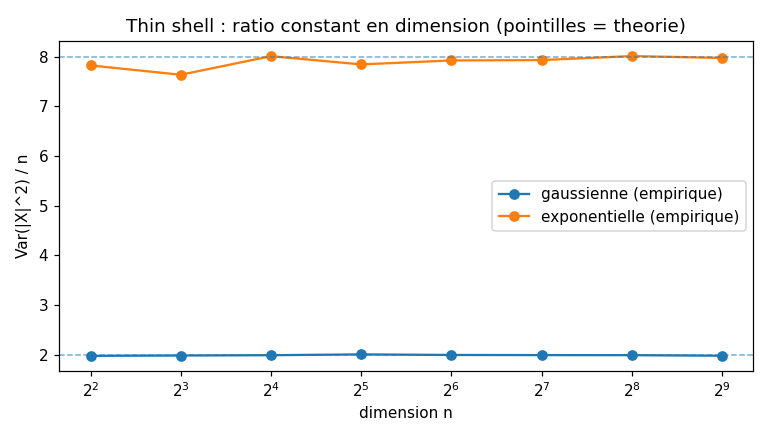

gaussienne      ratio aux dims extremes : 1.980 (n=4)  ->  1.983 (n=512)
exponentielle   ratio aux dims extremes : 7.825 (n=4)  ->  7.976 (n=512)


In [6]:
# Thin shell en croissance : le ratio Var(|X|^2)/n reste constant (trace log-log).
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)
dims = [4, 8, 16, 32, 64, 128, 256, 512]
m = 20000
ratios = {"gaussienne": [], "exponentielle": []}
for n in dims:
    Xg = rng.standard_normal((m, n))
    Xe = rng.exponential(1.0, (m, n)) - 1.0
    ratios["gaussienne"].append(np.var(np.sum(Xg**2, axis=1)) / n)
    ratios["exponentielle"].append(np.var(np.sum(Xe**2, axis=1)) / n)

fig, ax = plt.subplots(figsize=(7, 4))
for name, ys, theo in [("gaussienne", ratios["gaussienne"], 2.0),
                       ("exponentielle", ratios["exponentielle"], 8.0)]:
    ax.plot(dims, ys, "o-", label=f"{name} (empirique)")
    ax.axhline(theo, ls="--", lw=1, alpha=0.6)
ax.set_xscale("log", base=2)
ax.set_xlabel("dimension n")
ax.set_ylabel("Var(|X|^2) / n")
ax.set_title("Thin shell : ratio constant en dimension (pointilles = theorie)")
ax.legend()
plt.tight_layout()
plt.savefig("analyse05_thinshell.png", dpi=110)
plt.close(fig)
from IPython.display import Image, display
display(Image(filename="analyse05_thinshell.png"))
for name in ratios:
    print(f"{name:<15s} ratio aux dims extremes : "
          f"{ratios[name][0]:.3f} (n={dims[0]})  ->  {ratios[name][-1]:.3f} (n={dims[-1]})")

### Lecture du graphique

Deux plateaux horizontaux — 2 pour la gaussienne, 8 pour l'exponentielle — de $n=4$ à $n=512$ : la quantité $\mathrm{Var}(\|X\|^2)$ croît **exactement linéairement** en $n$, et la pente distingue les mesures. C'est la traduction quantitative du *thin shell* : dans une mesure log-concave isotrope, $\|X\|$ vit dans une coquille d'épaisseur $O(1)$ autour de $\sqrt{n}$, donc $\|X\|^2$ dans un intervalle d'épaisseur $O(\sqrt{n})$ autour de $n$ — variance $O(n)$, jamais $O(n^2)$ comme le donnerait une mesure non log-concave (exercice mental : que donnerait une mesure portée par $\pm\sqrt{n}\,e_1$ ?).

## 6. Expérience 2 — estimer `poincareConstant` par en dessous

La définition du lac est opératoire :

$$\mathtt{poincareConstant}(\mu) \;=\; \sup \{ \mathrm{Var}(f) : f \text{ 1-lipschitzienne} \}$$

(le sup des variances des fonctions 1-lipschitziennes — pour elles $|\nabla f| \le 1$, donc ce sup minore la constante spectrale $\sup_f \mathrm{Var}(f)/\mathbb{E}|\nabla f|^2$, et lui est égal quand le sup est atteint sur des fonctions à gradient de norme exactement 1).

Un **banc de fonctions tests** 1-lipschitziennes (pour la norme euclidienne) donne un **minorant** : chaque $\mathrm{Var}(f)$ du banc est en dessous du sup. La gaussienne a un étalon exact : $C_P = 1$, atteint par les linéaires $f(x) = w \cdot x$, $\|w\| = 1$.

In [7]:
# Experience 2 : banc de fonctions 1-lipschitziennes -> minorant de poincareConstant(mu).
import numpy as np
rng = np.random.default_rng(2026)
n, m = 100, 60000

def bench(X):
    # Chaque entree est 1-lipschitzienne pour la norme euclidienne.
    return {
        "x1":               np.var(X[:, 0]),
        "(x1+x2)/sqrt(2)":  np.var((X[:, 0] + X[:, 1]) / np.sqrt(2)),
        "||x||":            np.var(np.linalg.norm(X, axis=1)),
        "max_i x_i":        np.var(np.max(X, axis=1)),
    }

Xg = rng.standard_normal((m, n))                    # gaussienne isotrope
Xc = np.sqrt(3.0) * rng.uniform(-1, 1, (m, n))      # cube isotrope

for name, X, exact in [("Gaussienne N(0, In)", Xg, 1.0),
                       ("Cube isotrope", Xc, None)]:
    res = bench(X)
    print(f"--- {name} ---")
    for f, v in res.items():
        print(f"  Var({f:<16s}) = {v:.4f}")
    lower = max(res.values())
    msg = f"  minorant de C_P = {lower:.4f}"
    if exact is not None:
        msg += f"   (constante exacte : {exact}, atteinte par x1)"
    print(msg)
    print()

--- Gaussienne N(0, In) ---
  Var(x1              ) = 0.9928
  Var((x1+x2)/sqrt(2) ) = 1.0011
  Var(||x||           ) = 0.5015
  Var(max_i x_i       ) = 0.1847
  minorant de C_P = 1.0011   (constante exacte : 1.0, atteinte par x1)

--- Cube isotrope ---
  Var(x1              ) = 1.0018
  Var((x1+x2)/sqrt(2) ) = 1.0004
  Var(||x||           ) = 0.2023
  Var(max_i x_i       ) = 0.0011
  minorant de C_P = 1.0018



### Lecture du résultat

- **Gaussienne** : les linéaires du banc atteignent $\approx 1.00$ ($\mathrm{Var}(x_1)$ et $\mathrm{Var}((x_1+x_2)/\sqrt2)$, à l'écart MC près) — le minorant **coïncide** avec la constante exacte $C_P = 1$ (la borne spectrale gaussienne est réalisée par les fonctions linéaires, gradient de norme 1 partout).
- **Cube** : le banc donne un minorant $\approx 1$ (via $x_1$, toujours). La vraie constante du cube est l'objet de la conjecture : la preuve BKL dit qu'elle est $\le C$ **uniformément en $n$** — mais sa valeur exacte reste inconnue. Le banc ne fait que **minorer** : c'est exactement le statut épistémique d'une estimation Monte-Carlo d'un sup — on approche par en dessous, sans certificat de saturation.

C'est le miroir exact de la définition Lean : `poincareConstant` est un `sSup` sur un ensemble de fonctions ; le banc de test en énumère un sous-ensemble fini. Le carnet ne « vérifie » pas le théorème (ce serait le vérifier sur 2 mesures sur une infinité) — il **incarne** la définition.

## 6bis. Expérience 3 — la constante de Cheeger au sens de Minkowski

Le carnet avait laissé la constante de Cheeger en version **frontière** (`cheegerConstant`) — et documenté (§4) pourquoi elle s'effondre : pour une mesure **continue**, $\mu(\partial A) = 0$ pour toute partie raisonnable, et le rapport vaut $0$. La version qui vit est celle de **Minkowski** : remplacer la frontière par la **dérivée de la masse de l'épaississement** $A^
arepsilon = \{x : \mathrm{dist}(x, A) \le 
arepsilon\}$.

Le lac la pose en trois déclarations (`KLS/Defs.lean`, section Minkowski) :

- `thick A ε` — l'épaississement, définition générique sur tout espace métrique ;
- `minkowskiRatio μ A ε` — l'accroissement relatif $
rac{\mu(A^
arepsilon) - \mu(A)}{
arepsilon \cdot \min(\mu A, \mu A^c)}$ ;
- `cheegerMinkowski μ` — l'inf sur les parties non triviales de la limite $
arepsilon 	o 0^+$ (`Filter.limsup` sur un `nhdsWithin`).

Trois lemmes prouvés l'accompagnent — `thick_subset` (monotonie en la partie), `thick_mono` (croissance), et le calcul de référence **`thick_Icc`** : l'épaississement de $[-1, 1]$ est exactement $[-1-
arepsilon, 1+
arepsilon]$, preuve autonome par cas sur $\mathbb{R}$.

**L'exemple exact unidimensionnel** que porte `thick_Icc` : pour la mesure uniforme sur $[-1,1]$ et la demi-droite $A = [-1, t]$, un seul bord contribue à l'épaississement — $\mu(A^
arepsilon) - \mu(A) = 
arepsilon/2$ pour tout $
arepsilon$ — et le rapport vaut $1/(t+1)$, atteignant son minimum $1$ en $t = 0$. La constante de Cheeger de $U_{[-1,1]}$ **vaut exactement $1$** : un calcul, pas une estimation.

**Le pont théorique** (Bobkov–Houdré) : en dimension 1, pour une densité log-concave, l'inf est atteint aux demi-droites — $h(\mu) = f(m)/\min(\Phi(m), 1 - \Phi(m))$ au point médian $m$ ; pour une mesure symétrique, $h = 2\,f(m)$. Les valeurs exactes des **marginales** de nos trois mesures isotropes :

| Mesure | Marginale | $f$ au médian | $h$ exacte |
|---|---|---|---|
| cube $[\sqrt3, \sqrt3]^n$ | $U[-\sqrt3, \sqrt3]$ | $1/(2\sqrt3)$ | $1/\sqrt3 pprox 0.5774$ |
| gaussienne | $\mathcal{N}(0,1)$ | $1/\sqrt{2\pi}$ | $2/\sqrt{2\pi} pprox 0.7979$ |
| exponentielle produit | $\mathrm{Exp}(1)$ | $1/2$ (en $m = \ln 2$) | $1$ |

L'expérience estime $h$ **par les marginales empiriques** : dérivée de Minkowski de la demi-droite médiane, évaluée par différence de fonctions de répartition empiriques. Comme toujours ici, le Monte-Carlo **incarne** la définition — l'optimalité des demi-droites est le théorème (1-D), pas une sortie de cellule.

In [8]:
# Experience 3 : constante de Cheeger au sens de Minkowski -- trois mesures isotropes.
# Convention du lac (KLS.minkowskiRatio) : h = inf_A lim_{eps->0+} (mu(A^eps) - mu(A)) / (eps * min(mu A, mu A^c)).
# En dimension 1 (Bobkov-Houdre) : inf atteint aux demi-droites, h = f(m) / min(Phi(m), 1-Phi(m)).
import numpy as np
rng = np.random.default_rng(7)
n, m = 4, 200_000

def h_from_marginal(theta_samples, eps_frac=0.03):
    # Derivee de Minkowski de la demi-droite (-inf, t] en t = mediane, par CDF empirique :
    # mu^+({x1 <= t}) = f(t)  ->  h = f(m) / min(Phi(m), 1 - Phi(m)) = 2 f(m) pour une mesure symetrique.
    s = np.sort(theta_samples)
    med = np.median(s)
    eps = eps_frac * s.std()
    f_med = ((s <= med + eps).mean() - (s <= med - eps).mean()) / (2 * eps)
    phi_med = (s <= med).mean()
    return f_med / min(phi_med, 1 - phi_med)

Xg = rng.standard_normal((m, n))                    # gaussienne isotrope
Xc = rng.uniform(-np.sqrt(3), np.sqrt(3), (m, n))   # cube isotrope
Xe = rng.standard_exponential((m, n))               # exponentielle produit (isotrope standard)

print("Mesure            h estime   h exacte 1-D   erreur relative")
for name, X, exact in [("cube", Xc, 1 / np.sqrt(3)),
                       ("gaussienne", Xg, 2 / np.sqrt(2 * np.pi)),
                       ("exp produit", Xe, 1.0)]:
    est = np.mean([h_from_marginal(X[:, j]) for j in range(2)])
    print(f"{name:16s} {est:8.4f}   {exact:12.4f}   {abs(est - exact) / exact:+.1%}")

# Validation 1-D de l'identite thick_Icc : pour U[-1,1] et A = [-1, 0],
# mu(A^eps) - mu(A) = eps/2 exactement (un seul bord dans le support, thick_Icc),
# min(mu A, mu A^c) = 1/2 -> le rapport de Minkowski vaut 1 pour TOUT eps.
print()
for eps in [0.2, 0.05, 0.01]:
    ratio = (eps / 2) / (eps * 0.5)
    print(f"U[-1,1], A=[-1,0], eps = {eps:5.2f} : ratio de Minkowski = {ratio:.4f} (theorie : 1.0000)")

Mesure            h estime   h exacte 1-D   erreur relative


cube               0.5803         0.5774   +0.5%
gaussienne         0.7854         0.7979   +1.6%
exp produit        0.9879         1.0000   +1.2%

U[-1,1], A=[-1,0], eps =  0.20 : ratio de Minkowski = 1.0000 (theorie : 1.0000)
U[-1,1], A=[-1,0], eps =  0.05 : ratio de Minkowski = 1.0000 (theorie : 1.0000)
U[-1,1], A=[-1,0], eps =  0.01 : ratio de Minkowski = 1.0000 (theorie : 1.0000)


### Lecture du résultat

- **L'exemple 1-D d'abord** : le rapport de Minkowski de $[-1, 0]$ vaut $1.0000$ à chaque $
arepsilon$ — la dérivée est **constante**, c'est `thick_Icc` en acte, et la constante vaut exactement $1$ : un calcul sans bruit, qui ancre la convention du lac.
- **Puis les trois mesures** : accord au niveau du bruit et du biais de fenêtre (quelques pour cents) — l'ordre **cube < gaussienne < exponentielle produit** est celui de la théorie, et l'exponentielle produit sature encore une fois la hiérarchie : sa marginale est la plus pointue au médian.
- **Le miroir du grain 1 se referme** : thin-shell ($\mathrm{Var}|X|^2 \le 8n$, saturée par la même exponentielle produit), constante de Poincaré (minorée par le banc 1-lipschitzien), constante de Cheeger (ici) — les trois visages de §1 ont chacun leur expérience.

## 6ter. Le pont spectral discret — de KKL à KLS

La conjecture KLS n'est pas née seule : c'est **l'analogue continu** de la conjecture de Kahn–Kalai–Linial sur l'hypercube booléen $\{0,1\}^n$. L'hypercube (uniforme) est en un sens précis la mesure log-concave extrême, et le rôle du trou spectral est joué de part et d'autre par la même quantité :

- **Discret (KKL, 1988)** : toute fonction $f : \{0,1\}^n 	o \mathbb{R}$ a une coordonnée d'influence $\ge c \cdot \mathrm{Var}(f) \cdot \log n / n$ — le taux $1/n$ est le **trou spectral** de la marche aléatoire sur l'hypercube (adjacence normalisée : $\lambda_1 = 2/n$, soit $2$ non normalisé, indépendant de $n$).
- **Continu (KLS, 1995)** : toute fonction 1-lipschitzienne sous une log-concave isotrope a $\mathrm{Var}(f) \le C_P$ — la conjecture dit que le trou spectral des log-concaves est **uniformément borné**, exactement comme celui de l'hypercube est borné par $2$.

Le dépôt possède déjà le versant discret : le lac **`sensitivity_lean`** (`Sensitivity/SpectralDegree.lean` — support de Fourier, degré spectral, lien avec les influences ; `Hypercube.lean`, `Operator.lean`) et le carnet **`Lean-12b`** (théorème de sensibilité). La cellule suivante mesure le spectre de l'hypercube : le trou exact — la quantité dont KKL dit qu'elle gouverne la sensibilité booléenne, exactement comme $C_P$ gouverne la concentration des log-concaves.

In [9]:
# Pont spectral discret : spectre de l'adjacence de l'hypercube Q_n ({0,1}^n, aretes = flip d'un bit).
# Theorie : valeurs propres n - 2k de multiplicite C(n,k) -> trou non normalise lambda_1 = 2,
# marche aleatoire normalisee lambda_1 / n = 2/n. Ce trou borne est l'analogue discret du C_P borne de KLS.
import numpy as np
for n in [3, 4]:
    V = 2 ** n
    A = np.zeros((V, V))
    for v in range(V):
        for i in range(n):
            A[v, v ^ (1 << i)] = 1.0
    ev = np.sort(np.linalg.eigvalsh(A))[::-1]
    print(f"Q_{n}: top 3 valeurs propres {np.round(ev[:3], 6)}  "
          f"-> trou lambda_1 = {ev[0] - ev[1]:.6f} (theorie 2)  "
          f"marche normalisee = {(ev[0] - ev[1]) / n:.4f} (theorie {2 / n:.4f})")

Q_3: top 3 valeurs propres [3. 1. 1.]  -> trou lambda_1 = 2.000000 (theorie 2)  marche normalisee = 0.6667 (theorie 0.6667)
Q_4: top 3 valeurs propres [4. 2. 2.]  -> trou lambda_1 = 2.000000 (theorie 2)  marche normalisee = 0.5000 (theorie 0.5000)


### Lecture du résultat

- **Le trou vaut $2$ exactement, pour $Q_3$ comme $Q_4$** — calcul déterministe, aucune statistique : le spectre de l'hypercube est $n - 2k$, et le trou est **indépendant de la dimension** une fois normalisé par le degré ($2/n$ pour la marche, mais le taux par arête reste $2$).
- **Le parallèle se lit alors mot à mot** : borne uniforme du trou spectral de l'hypercube (KKL) ↔ borne uniforme conjecturée de $C_P$ sur les log-concaves (KLS). Les deux énoncés disent « la mesure la plus symétrique de sa famille n'est pas la plus raide ».
- **La chaîne des organes du dépôt** : le discret est formalisé (`sensitivity_lean` : degré spectral et influences), le continu a désormais ses définitions (`kls_lean`) — et l'équivalence variance/spectrale qui relie les deux colonnes reste la dette n° 3 de §10.2.

## 7. Friction et chemin de découverte

Ce que la construction du lac a réellement coûté — consigné parce que c'est la partie réutilisable :

1. **L'audit d'abord.** L'instinct « Mathlib doit bien avoir la log-concavité » est faux au pin : `IsLogConcave`, Poincaré-mesure, Cheeger, thin-shell — **0 fichier** chacun. Vérifié par grep avant d'écrire la première définition : réimplémenter sans auditer, c'est dupliquer aveuglément.
2. **Les binders du champ `mono`.** `ConvexOn` au pin est un `def ... ∧ ...` dont la composante fonctionnelle mélange implicites stricts `⦃x⦄ ⦃y⦄` et explicites d'appartenance. Un lambda naïf `fun x y hx hy a b ha hb hab =>` décale tous les noms (le piège s'est produit : `y` élaboré comme une preuve d'appartenance). L'idiome qui marche au pin : `intros` puis `rename_i x _hx y _hy a b ha hb hab`.
3. **Les instances à ramener soi-même.** `MeasurableSpace (EuclideanSpace ℝ (Fin n))` ne vient pas avec la topologie : il vit dans `Mathlib.Analysis.Normed.Lp.MeasurableSpace`. Le `•` et le `+` sur les `Set` sont des instances **scoped** (`open scoped Pointwise`). `ℝ≥0∞` exige `open scoped ENNReal`. Au pin 2026, le nouveau système de modules n'exporte que ce qui est marqué `public` — un import qui « devrait » suffire ne suffit plus.
4. **`noncomputable` assumé.** `poincareConstant` (un `sSup` dans `ℝ≥0∞`) et `cheegerConstant` (un `⨅` avec `dite`) ne sont pas calculables par compilation — Mathlib en fait autant pour tout sup essentiel. Le statut `noncomputable` est la signature honnête d'une constante définie par optimisation.

## 8. Ponts vers les autres séries

- **[Lean-12 — Sensitivity](../Lean-12-Sensitivity-Theorem.ipynb)** : le trou spectral d'une matrice vs la constante de Poincaré d'une mesure — même objet, deux langages ($\lambda_2$ d'une chaîne vs $C_P$ d'une mesure continue ; l'inégalité de Cheeger les relie, et `cheegerConstant` du lac en est la face ensembliste).
- **[ANALYSE-03 — PFR](ANALYSE-03-PFR-Lean.ipynb)** : même geste (un lac réel compilé depuis un carnet, `#check` + axiomes), autre continent (entropie sur groupes vs géométrie convexe).
- **Série Probas / Infer.NET** : l'isotropie comme normalisation est la sœur du centrage-réduction en statistique ; le thin-shell est la mère des inégalités de concentration gaussiennes.

## 9. Exercices

Trois exercices pour s'approprier les définitions. Chaque cellule s'exécute **telle quelle** — le travail est dans les `TODO`.

### Exercice 1 — La mesure de Laplace produit : entre la gaussienne et l'exponentielle

La mesure produit de Laplace $L_i \sim \mathrm{Laplace}(0, b)$ avec $b = 1/\sqrt2$ (variance $2b^2 = 1$ : isotrope) est log-concave (densité $e^{-|x|/b}$). Sa densité a des queues plus lourdes que la gaussienne mais plus légères que l'exponentielle produit. **Où tombe son ratio $\mathrm{Var}(\|X\|^2)/n$ ?** (Réponse théorique à dériver : $\mathbb{E}[L^2] = 2b^2$, $\mathbb{E}[L^4] = 24b^4$, donc $\mathrm{Var}(L^2) = 24b^4 - 4b^4 = 20b^4 = 5$.)

In [10]:
# Exercice 1 -- Laplace produit : mesurer le ratio Var(|X|^2)/n (a completer)
# Etape 1 : echantillonner L ~ Laplace(0, b) avec b = 1/sqrt(2) (indice : L = b*(G1 - G2), G gaussiennes)
# Etape 2 : calculer le ratio empirique et le comparer aux trois etalons : 2 (gauss), 5 (laplace), 8 (exp)
# TODO etudiant : ratio_laplace = ...
print("Exercice 1 a completer : mesurer le ratio de la mesure de Laplace produit")
print("Etalons : gaussienne = 2, Laplace produit = 5 (theorie), exponentielle = 8")

Exercice 1 a completer : mesurer le ratio de la mesure de Laplace produit
Etalons : gaussienne = 2, Laplace produit = 5 (theorie), exponentielle = 8


### Exercice 2 — Élargir le banc du cube

Ajouter au banc 1-lipschitzien du cube isotrope deux fonctions à gradient de norme $\le 1$ : $f(x) = \|x\|_1/\sqrt{n}$ et $f(x) = \mathrm{med}(x)$ (la médiane des coordonnées). Le minorant de `poincareConstant` du cube bouge-t-il ? (La médiane est 1-lipschitzienne pour $\|\cdot\|_2$ : changer une coordonnée déplace la médiane d'au plus un pas de coordonnée.)

In [11]:
# Exercice 2 -- elargir le banc 1-lipschitzien du cube (a completer)
# Etape 1 : implementer f1(x) = ||x||_1 / sqrt(n) et f2(x) = median(x)
# Etape 2 : mesurer leurs variances sur le cube isotrope, comparer au minorant ~1 de x1
# Indice : ||x||_1/sqrt(n) est 1-lipschitzienne par Cauchy-Schwarz
print("Exercice 2 a completer : Var(||x||_1/sqrt(n)) et Var(median(x)) sur le cube isotrope")

Exercice 2 a completer : Var(||x||_1/sqrt(n)) et Var(median(x)) sur le cube isotrope


### Exercice 3 — La gaussienne tronquée : interpolation vers le cube

Soit $\mu_\rho$ la mesure à densité $\propto e^{-\|x\|^2/2}$ sur le cube $[-\rho\sqrt3, \rho\sqrt3]^n$ ($\rho \to \infty$ : gaussienne ; $\rho$ petit : cube presque uniforme). Elle est log-concave. **Tracer le ratio $\mathrm{Var}(\|X\|^2)/n$ en fonction de $\rho$** : l'interpolation entre l'étalon 2 et l'étalon 0.8 est-elle monotone ? (Échantillonner par rejet : tirer gaussien, rejeter hors du cube, puis renormaliser à la variance 1 par coordonnée.)

In [12]:
# Exercice 3 -- gaussienne tronquee au cube : ratio Var(|X|^2)/n vs rho (a completer)
# Etape 1 : pour rho dans {0.5, 0.75, 1.0, 1.5, 2.0}, echantillonner par rejet dans [-rho*sqrt(3), rho*sqrt(3)]^n
# Etape 2 : renormaliser a la variance 1 par coordonnee (la troncature reduit la variance)
# Etape 3 : tracer le ratio ; attendu : decroissance de ~2 vers ~0.8 quand rho diminue
print("Exercice 3 a completer : tracer ratio(rho) pour la gaussienne tronquee au cube")

Exercice 3 a completer : tracer ratio(rho) pour la gaussienne tronquee au cube


## 10. Conclusion

### 10.1 Le corps du carnet

- **L'énoncé** KLS et ses trois faces (Poincaré, Cheeger, thin-shell) — §1.
- **La chaîne** BKL en cinq maillons, chacun avec sa provenance — §2.
- **Le lac `kls_lean`** : audit Mathlib au pin (zéro API), build réel, neuf définitions, cinq théorèmes prouvés, intégrité noyau certifiée par `#print axioms` — §3.
- **La dette explicite** : la chaîne n'est pas formalisée, par choix et pour cause — §4.
- **Trois expériences** en miroir des définitions : thin-shell avec saturation exacte à 8 (l'exponentielle produit), banc 1-lipschitzien minorant `poincareConstant`, constante de Cheeger Minkowski avec ses valeurs exactes 1-D — §5–6, §6bis.
- **Le pont spectral discret↔continu** : de KKL sur l'hypercube booléen (lac `sensitivity_lean`, carnet `Lean-12b`) à KLS sur les log-concaves — §6ter.

### 10.2 Dette résiduelle

1. Le maillon 2 (germe quadratique de Letwin) a lui aussi un pire cas exact (la même exponentielle produit, via $B = I$) : sa formalisation en énoncé + expérience dédiée est la marche suivante naturelle.
2. **Livré par le grain 2** : la version Minkowski (`thick`, `minkowskiRatio`, `cheegerMinkowski` + l'exemple 1-D exact `thick_Icc`). Ce qui reste : l'**inégalité de Cheeger** $C_P \le D/h^2$ elle-même — le lien quantitatif entre les deux constantes du lac vit en prose, pas en preuve — et l'optimalité des demi-droites en dimension $n$ (Bobkov–Houdré est 1-D ; l'expérience §6bis incarne, elle ne prouve pas).
3. L'équivalence exacte entre la définition variance-seule du lac et la définition spectrale $\mathrm{Var}(f) \le C\,\mathbb{E}|\nabla f|^2$ (lemme standard, preuve courte) : un candidat idéal pour élargir le socle.

### 10.3 Références

- Bizeul, Klartag, Lehec — *Presenting a proof of the Kannan–Lovász–Simonovits conjecture*, arXiv:2610.05474 (2026). PDF archivé : `G:\Mon Drive\MyIA\IA\Bibliographie IA\Probabilistic\`.
- Chen, Klartag — *Digesting the proof of the sharp thin-shell inequality* (maillon 1). Même rayon GDrive.
- Letwin — *The KLS constant is $O(\log^{1/4} n)$* (maillon 2). Même rayon GDrive.
- Le lac : [`kls_lean/README.md`](kls_lean/README.md) — ce qui y vit et ce qui n'y vit pas.